In [198]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.api import ARIMA
from scipy.stats import skew, kurtosis

### 1

$ r_{t}=\mu +\sigma \varepsilon _{t}+J_{t}\ and \ J_{t}=B_{t}\times \left( \mu _{j}+\sigma _{j}\delta _{t}\right) $$

The expectation is as follows:
$$ E\left[ r_{f}\right] =\mu +p\mu _{j}  $$

The variance is as follows:
$$ Var\left[ r_{t}\right] =p\mu _{j}^{2}\left( 1-p\right) +p^{2}\sigma _{j}^{2}+\sigma ^{2} $$

The skew is derived as follows:
Skew = $$ \dfrac{E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{3}\right] }{\ {var}\left( r_{t}\right) ^{3/2}} $$
$$ r_{t}-E\left[ r_{t}\right]  = \mu +\sigma \varepsilon _{{t}}+J_{t} -\mu -p\mu _{j}= \sigma \varepsilon _{t} + J_{t}-p\mu _{j} $$
$$ \mathbb{E}\!\left[\left(\sigma \varepsilon_t + (J_t - p\mu_j)\right)^3\right] $$

$$ \mathbb{E}\!\left[(\sigma\varepsilon_t + (J_t-p\mu_j))^3\right]
= \mathbb{E}\!\left[(\sigma\varepsilon_t)^3\right] + \mathbb{E}\!\left[(J_t-p\mu_j)^3\right] + 3\,\mathbb{E}\!\left[(\sigma\varepsilon_t)^2\right]\mathbb{E}\!\left[J_t-p\mu_j\right] + 3\,\mathbb{E}\!\left[\sigma\varepsilon_t\right]\mathbb{E}\!\left[(J_t-p\mu_j)^2\right]. $$


 Given that: $$ E\left[ \left( \sigma \varepsilon _{t}\right) \right] =\sigma E\left[ \varepsilon _{t}\right] =\sigma0 $$ and also $$E\left[ J_t\right] =p\mu _{i} E[ J_t\ -p\mu _{j}] =0 $$

$$\mathbb{E}\!\left[(J_t-p\mu_j)^3\right] = \mathbb{E}[J_t^3] -3p\mu_j\,\mathbb{E}[J_t^2] +3(p\mu_j)^2\,\mathbb{E}[J_t] -E[(p\mu_j)^3] $$

$$ = p\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right) -3p\mu _{j}p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) +3\left( p\mu _{j}\right) ^{3}-\left( p\mu _{j}\right) ^{3} =
3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) $$

So skew is equal to:

 $$=\dfrac{3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) } {\left( p\mu _{j}^{2}\left(1-p\right) +p\sigma _{j}^{2}+\sigma ^{2}\right) ^{3/2}} $$

Lastly the Kurtosis is derived as follows:
$$ K\left( r_{t}\right) =E\left[ \dfrac{\left( r_{t}-E\left[ r_{t}\right] \right) ^{4}}{var\left( r_{t}\right) ^{2}}\right] $$

using $$ r_{t}-E\left[ r_{t}\right] = \sigma \varepsilon _{t}+J _{t}-p\mu _{j} $$

$$ E\left[ \left( \sigma \varepsilon _{t}+J_{t}-p\mu _{j}\right) ^{4}\right] = E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right] +4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] + 6\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)^2\left(J_t-p\mu_j\right)^2\right] +4\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)\left(J_t-p\mu_j\right)^3\right] +\mathbb{E}\!\left[\left(J_t-p\mu_j\right)^4\right]$$

But we have
1) $$E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right]  $$ leads to $$ 3\sigma ^{4}$$ from normal distribution having kurtosis 3.
2) $$ 4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] $$ and $$4E\left[ (\sigma \varepsilon _{t})\left( J_{t}-p\mu _{j}\right) ^{3}\right] \ =0 $$

Thus we get: $$3\sigma ^{4}+6\sigma ^{2}\left[ p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -\left( p\mu _{j}\right) ^{2}\right] +p\left( \mu _{j}^{4}+6\mu _{j}^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^2{\mu_j}\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right)
 +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j}\right) ^{4}$$

Which simplifies to:
$$ E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{4}\right] =3\sigma ^{4}+6\sigma ^{2}\left[ p\mu _{j}^{2}\left( 1-p\right) +p\sigma _{j}^{2}\right] +
p\left( \mu _{j}^{4}+6\mu_j^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^{2}\mu _{j}\left( \mu _{j}^{3}+3\mu _{j}\sigma _{j}^{2}\right) +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j }\right) ^{4} $$

So:
$$ \begin{aligned} K(r_t) &= \frac{\mathbb{E}\!\left[\left(r_t-\mathbb{E}[r_t]\right)^4\right]} {\left(p(1-p)\mu_j^2 + p\sigma_j^2 + \sigma^2\right)^2}. \end{aligned} $$

Meaning thus excess kurtosis is:  $$ K\left( r_{t}\right) -3$$


### 2

In the log normal returns model we have:
$$r_t = \mu + \sigma \epsilon_t$$
where $r_t$ are the log returns, and $r_t \sim \mathcal{N}(\mu, \sigma^2)$.

In this case, the skewness of the model is:
$$\frac{E[(r_t-E[r_t])^3]}{\sigma^3} = 0$$

And the kurtosis:
$$\frac{E[(r_t-E[r_t])^4]}{\sigma^4} = 3$$

This means that under the log normal returns model we are expecting normal returns, that is symmetric, and no fat tails to it.

In contrast, when modelling returns we expect a left tail that is more pronounced than the right tail (negative skewness). That is because, many investments with high Sharpe ratios have strongly negatively skewed returns. In addition, returns generally show fat tails, so the kurtosis should be greater than 3. This is because when talking about returns, it is more likely to have an extreme scenario (eg. crashes) than it would be predicted by normal distributions.

Finally, the Bernoulli-normal mixture introduces jumps to the model. This jump means that shocks come periodically, without assuming a continuous and smooth release of information.

For these reasons, the Bernoulli-normal mixture is potentially a better model of returns

In [199]:
def normal_log_returns(T):
    return np.random.normal(loc=0.0004, scale=0.1**2, size=T)


def jump_log_returns(mu, sigma, p, mu_j, sigma_j, T):
    bt = np.random.binomial(n=1, p=p, size=T)
    jt = bt * (mu_j + sigma_j * np.random.normal(loc=0, scale=1, size=T))
    rt = mu + sigma * np.random.normal(loc=0, scale=1, size=T) + jt
    return rt

In [200]:
jump_sim = jump_log_returns(0.0004, 0.01, 0.01, -0.03, 0.04, 2500)
log_ret = normal_log_returns(12_500)
t = np.linspace(1, 12_500/250, num=len(log_ret))
t2 = np.linspace(1, 2500/250, num=len(jump_sim))
real_returns = pd.read_csv('homework3data.csv')
real_returns['year'] = real_returns['year'].astype(str)
real_returns['month'] = real_returns['month'].astype(str)
real_returns['date'] = real_returns['year'] + '-' + real_returns['month']
real_returns['date'] = pd.to_datetime(real_returns['date'], format='%Y-%m')

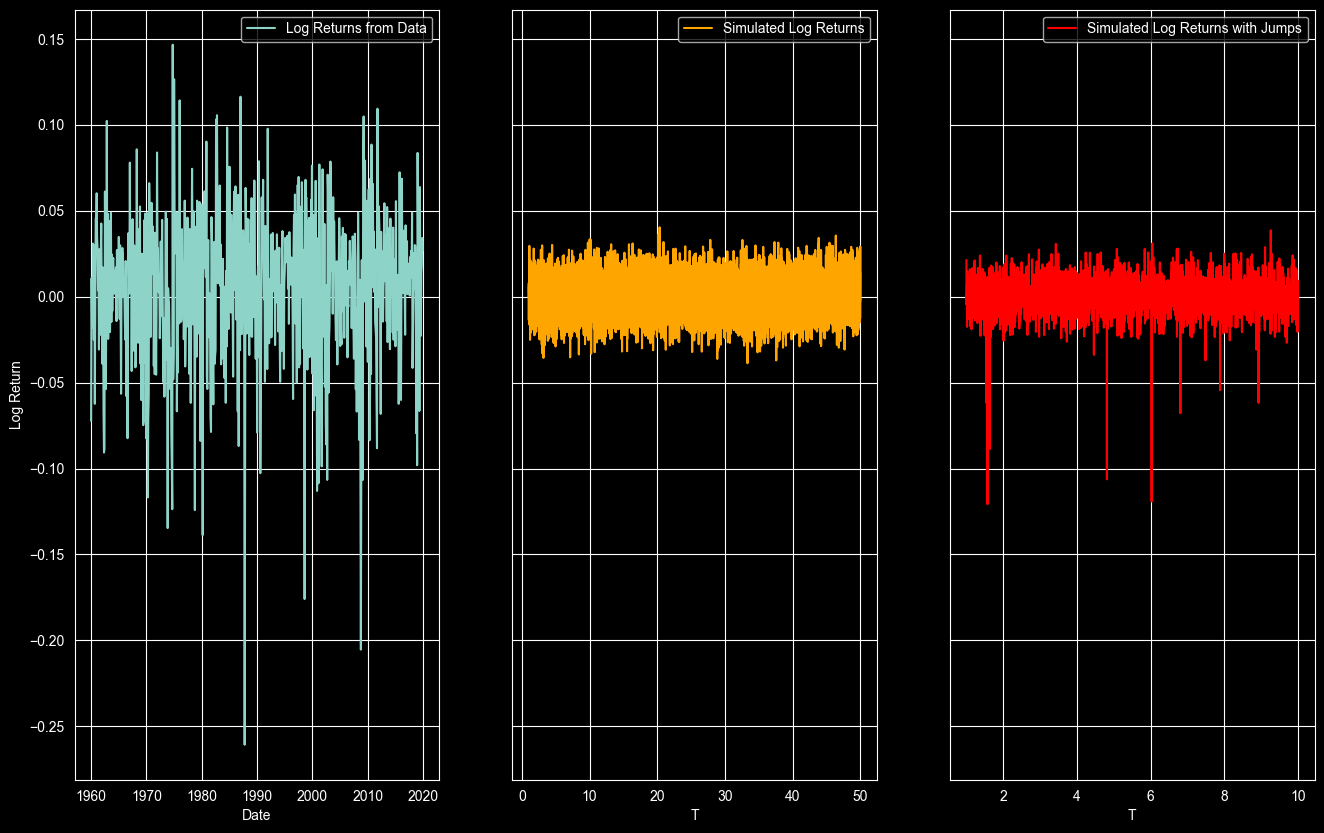

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10), sharey=True)
sns.lineplot(data=real_returns, x='date', y='log_excess_ret', ax=axes[0], label='Log Returns from Data')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
sns.lineplot(x=t, y=log_ret, label='Simulated Log Returns', ax=axes[1], color='orange')
axes[1].set_xlabel('T')
sns.lineplot(x=t2, y=jump_sim, label='Simulated Log Returns with Jumps', ax=axes[2], color='red')
axes[2].set_xlabel('T')
plt.show()

The basic log return model doesn't capture the full dynamics of the real world data. The real world data is much more volatile with periods of extreme volatility and plenty of outlier returns. The basic log return model is missing a jump component to model the crashes seen in the data.
Once we add in the jumps the model looks more like the data but still is not quite the same. We are missing a stochastic volatility component. The real world data exhibits volatility clustering that is not being captured by our Bernoulli-normal mixture model. In order to correct for this, we need our $\sigma$ component to vary through time. With properly estimated parameters, this would allow for the volatility clustering to be captured by our model. Furthermore, we can add in different kinds of jumps. There are some jumps that happen at known times, such as earnings releases, but there are also random jumps. By adding in two different jump components we could more accurately capture the timing of the jumps themselves. With stochastic volatility, pre-determined jumps, and random jumps we would have a much better model of returns.

In [202]:
log_mean = np.mean(log_ret)
log_std = np.std(log_ret)
log_skew = skew(log_ret)
log_kurtosis = kurtosis(log_ret, fisher=False)

jump_mean = np.mean(jump_sim)
jump_std = np.var(jump_sim)
jump_skew = skew(jump_sim)
jump_kurtosis = kurtosis(jump_sim, fisher=False)

pd.DataFrame({'Log Normal': [log_mean, log_std, log_skew, log_kurtosis],
              'Bernoulli': [jump_mean, jump_std, jump_skew, jump_kurtosis]},
             index=['Mean', 'SD', 'Skewness', 'Kurtosis'])

,Log Normal,Bernoulli
Mean,0.000400,-0.000045
SD,0.010000,0.000122
Skewness,-0.029948,-1.774256
Kurtosis,3.042512,19.642657


In [203]:
mu = 0.0004
sigma = 0.01
p = 0.01
mu_j = -0.03
sigma_j = 0.04

unconditional_mu = mu + p * mu_j
unconditional_variance = p * mu_j**2 * (1 - p) + p * sigma_j**2 + sigma**2
unconditional_skew = (3 * p * mu_j * sigma_j ** 2 * (1 - p) + p * mu_j**3 * (1- 3*p + 2 * p**2)) / ((p * mu_j**2 * (1-p) + p * sigma_j**2 + sigma**2) ** (3/2))
print(f'Unconditional Mean: {unconditional_mu}')
print(f'Unconditional SD: {np.sqrt(unconditional_variance)}')
print(f'Unconditional Skew: {unconditional_skew}')

Unconditional Mean: 0.00010000000000000005
Unconditional SD: 0.011176314240392492
Unconditional Skew: -1.2088206383710394


# 4
Here we want to find the t-stat of the sample mean. In this case, the t-stat is given by:
$$t = \frac{\bar{r}-E[r_t]}{\sqrt{Var(\bar{r})}}$$

where:
$$\bar{r} = \frac{1}{T}\sum_{t=1}^Tr_t = \frac{1}{T}\sum_{t=1}^T(\mu + \sigma \epsilon_t + B_t(\mu_J + \sigma_J \delta_t)) = \mu + \frac{1}{T}\sigma \sum_{t=1}^T\epsilon_t + \frac{1}{T}\sum_{t=1}^T B_t(\mu_J + \sigma_J \delta_t)$$

From Question 1:
$$E[r_t] = \mu + p\mu_J$$

and the variance is given by:

$$Var(\bar{r}) = Var(\frac{1}{T}\sum_{t=1}^Tr_t)= \frac{1}{T^2}Var(\sum_{t=1}^Tr_t)$$
since we are assuming no autocorrelation we get:
$$\frac{1}{T^2}Var(\sum_{t=1}^Tr_t) = \frac{1}{T^2}\sum_{t=1}^TVar(r_t) = \frac{1}{T}Var(r_t)$$

operate under the null hypothesis that the population mean is zero:
$$H_0: E[r_t] = 0$$
This means that:
$$E[r_t] = \mu + p\mu_J = 0 \Rightarrow \mu = -p\mu_J $$

In [204]:
def samples_bernoulli(T):
    rt = jump_log_returns(mu, sigma, p, mu_j, sigma_j, T)
    return rt

def t_statistic(rt):
    T = len(rt)
    mean = np.mean(rt)
    var_mean = np.var(rt)
    std_mean = np.sqrt(var_mean / T)

    return mean / std_mean, mean

def monte_carlo(N, T):
    t_stats = np.zeros(N)
    sample_means = np.zeros(N)

    for nn in range(N):
        rt = samples_bernoulli(T)
        t_stats[nn] = t_statistic(rt)[0]
        sample_means[nn] = t_statistic(rt)[1]

    return t_stats, sample_means


def distribution_plots(year, t_stats, sample_means):

    print(f'Distribution plots for {year/250} years.')

    stand_norm = np.random.normal(0, 1, N)
    sns.histplot(x=t_stats[year], color='blue', label='t-stat')
    sns.histplot(x=stand_norm, color='red', alpha=0.3, label='Standard Normal')
    plt.title('Distribution of t-stat under $H_0$ vs. Standard Normal')
    plt.legend()
    plt.show()

    sns.histplot(x=sample_means[year], color='blue', label='Sample mean')
    plt.title('Distribution of sample means')
    plt.show()

Distribution plots for 0.1 years.


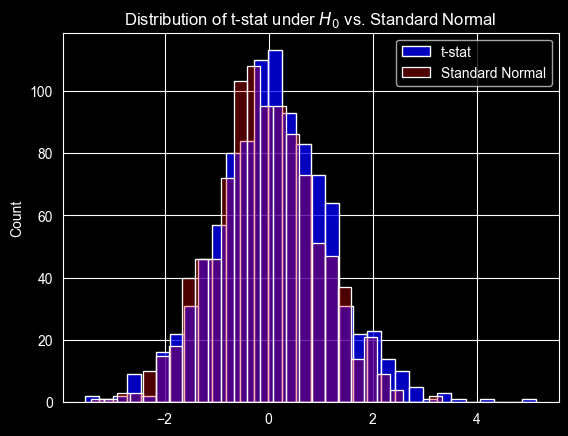

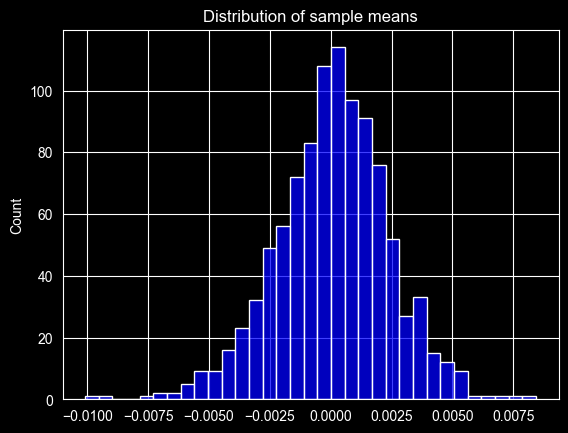

Distribution plots for 0.5 years.


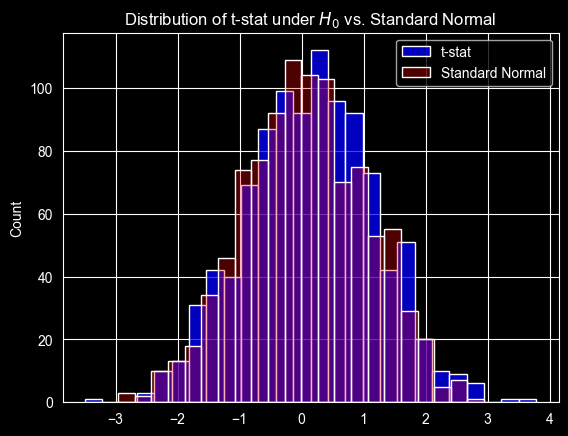

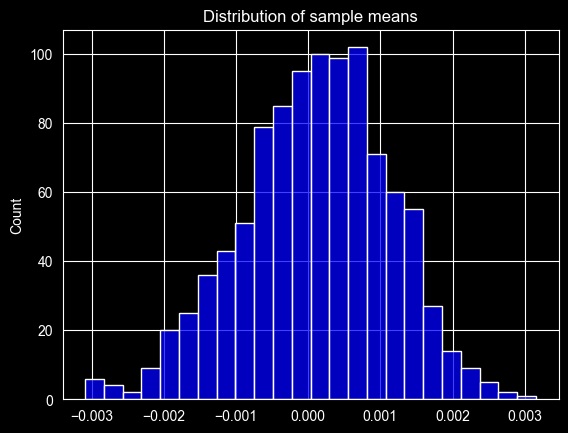

Distribution plots for 2.0 years.


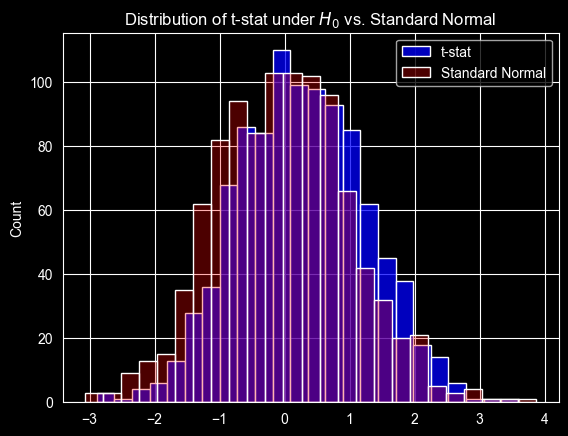

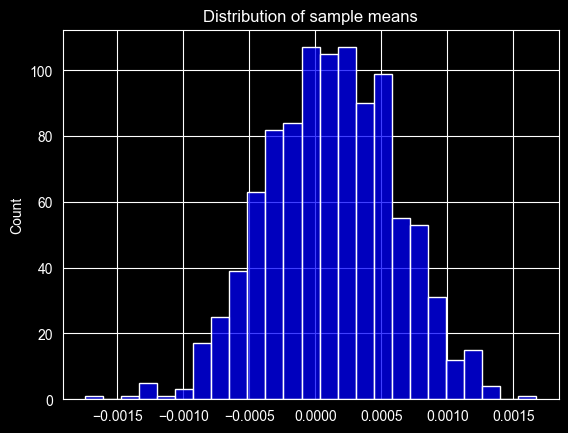

Distribution plots for 4.0 years.


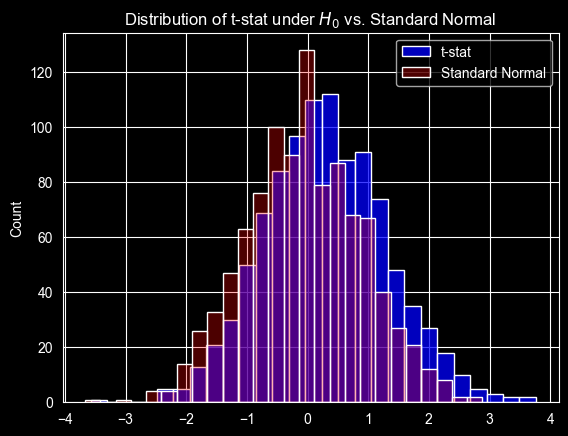

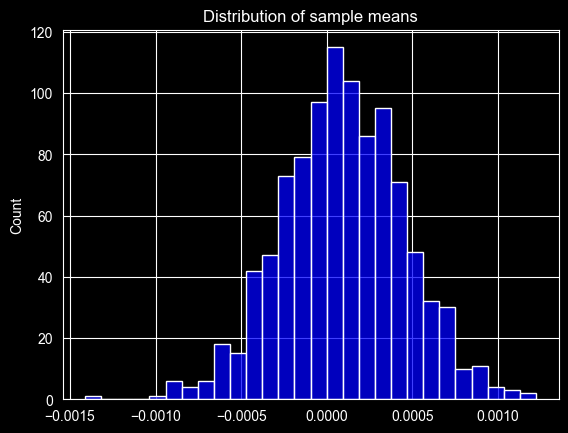

In [205]:
N = 1000
T = [25, 125, 500, 1000]
t_stats_dict = dict()
sample_mean_dict = dict()

for year in T:
    t_stats, sample_mean = monte_carlo(N, year)
    t_stats_dict[year] = t_stats
    sample_mean_dict[year] = sample_mean
    distribution_plots(year, t_stats_dict, sample_mean_dict)

In [206]:
for year in T:
    print(f'The t-stat and sample mean moments for {year} years:')
    df = pd.DataFrame({'t-stat': [np.mean(t_stats_dict[year]), np.std(t_stats_dict[year]), skew(t_stats_dict[year]), kurtosis(t_stats_dict[year])],
                        'Sample Mean': [np.mean(sample_mean_dict[year]), np.std(sample_mean_dict[year]), skew(sample_mean_dict[year]), kurtosis(sample_mean_dict[year])]},
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])
    print(df)

The t-stat and sample mean moments for 25 years:
            t-stat  Sample Mean
Mean      0.104572     0.000085
STD       1.100171     0.002305
Skewness  0.164190    -0.240415
Kurtosis  0.678589     0.767385
The t-stat and sample mean moments for 125 years:
            t-stat  Sample Mean
Mean      0.150714     0.000100
STD       1.040048     0.001024
Skewness -0.001362    -0.259540
Kurtosis -0.114869    -0.007522
The t-stat and sample mean moments for 500 years:
            t-stat  Sample Mean
Mean      0.269856     0.000122
STD       0.980216     0.000484
Skewness  0.037060    -0.091905
Kurtosis -0.149542    -0.047232
The t-stat and sample mean moments for 1000 years:
            t-stat  Sample Mean
Mean      0.292926     0.000096
STD       1.016825     0.000358
Skewness  0.091406    -0.065916
Kurtosis  0.129311     0.239243


# Question 2
### 1

In [207]:
real_returns['rt+1'] = real_returns['log_excess_ret'].shift(-1) * 12
real_returns.dropna(inplace=True)
X = real_returns['div_yld']
X = add_constant(X)
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt+1']

In [208]:
reg = OLS(y, X).fit(cov_type='HC3')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.218
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0226
Time:                        21:30:38   Log-Likelihood:                -557.43
No. Observations:                 719   AIC:                             1119.
Df Residuals:                     717   BIC:                             1128.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha              0.1984      0.064      3.098      0.002       0.073       0.324
dividend_yield    -5.2511      2.299     -2.284      0.022      -9.757      -0.745
==============================================================================
Omnibus:                      108.222   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.555
Skew:                          -0.753   Prob(JB):                     7.36e-67
Kurtosis:                       5.810   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [209]:
print(reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -5.2511      2.299     -2.284      0.022      -9.757      -0.745


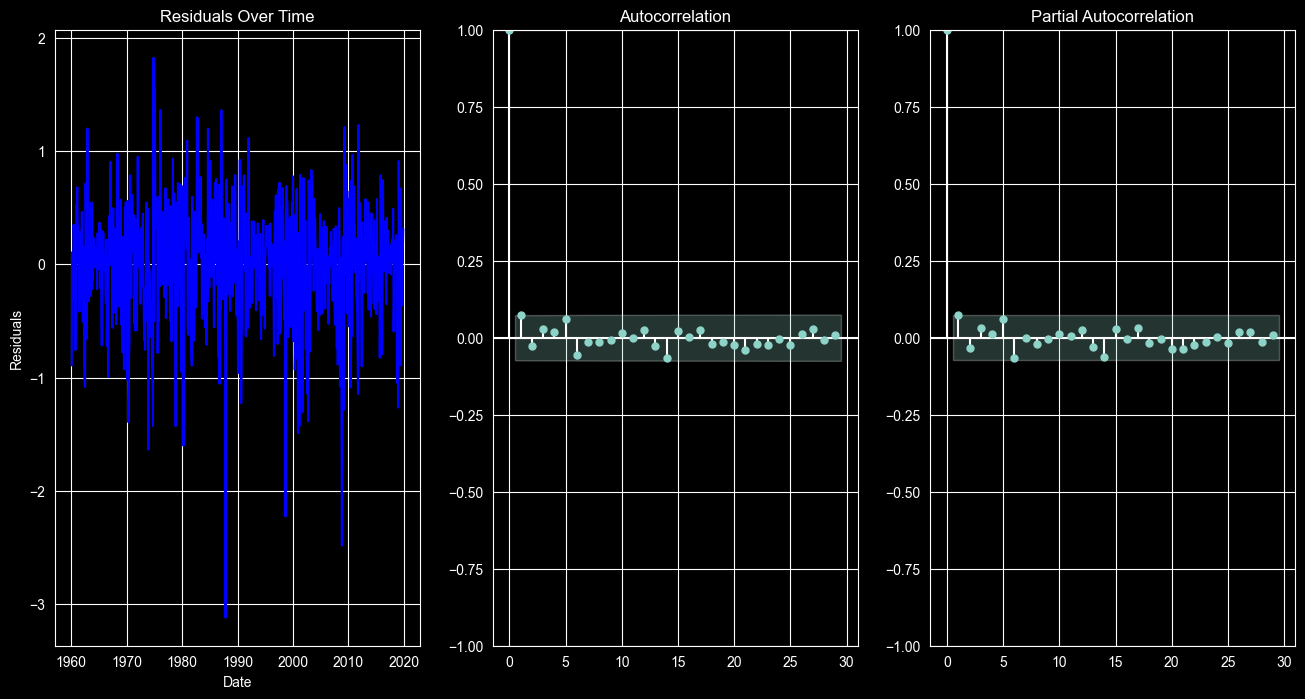

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals Over Time')
acf = plot_acf(x=reg.resid, ax=axes[1])
pacf = plot_pacf(x=reg.resid, ax=axes[2])
plt.show()

### 2



In [211]:
from statsmodels.tsa.stattools import adfuller

In [212]:
adfuller(real_returns['div_yld'], autolag='AIC')[1]

np.float64(0.4787474874351325)

<Axes: >

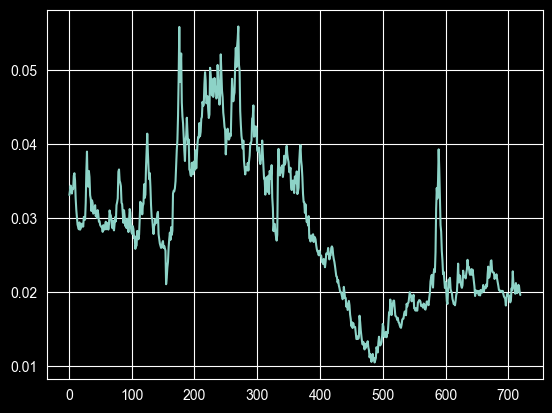

In [213]:
real_returns['div_yld'].plot()

### 3

In [214]:
rtk_k = real_returns['log_excess_ret'].shift(-1)
for i in range(2, 13):
    rtk_k += real_returns['log_excess_ret'].shift(-i)

real_returns['rt12_12'] = rtk_k
real_returns.dropna(inplace=True)

In [215]:
X = add_constant(real_returns['div_yld'])
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt12_12']

In [216]:
overlap_reg = OLS(y, X).fit(cov_type='HC3')
overlap_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     22.09
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           3.13e-06
Time:                        21:30:38   Log-Likelihood:                 296.06
No. Observations:                 707   AIC:                            -588.1
Df Residuals:                     705   BIC:                            -579.0
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0288      0.019     -1.538      0.124      -0.066       0.008
dividend_yield     2.7782      0.591      4.700      0.000       1.620       3.937
==============================================================================
Omnibus:                      101.581   Durbin-Watson:                   0.138
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.732
Skew:                          -0.971   Prob(JB):                     6.84e-34
Kurtosis:                       4.190   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [217]:
print(overlap_reg.t_test('dividend_yield = 0'))
print(f'R-Squared: {0.029}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.7782      0.591      4.700      0.000       1.620       3.937
R-Squared: 0.029


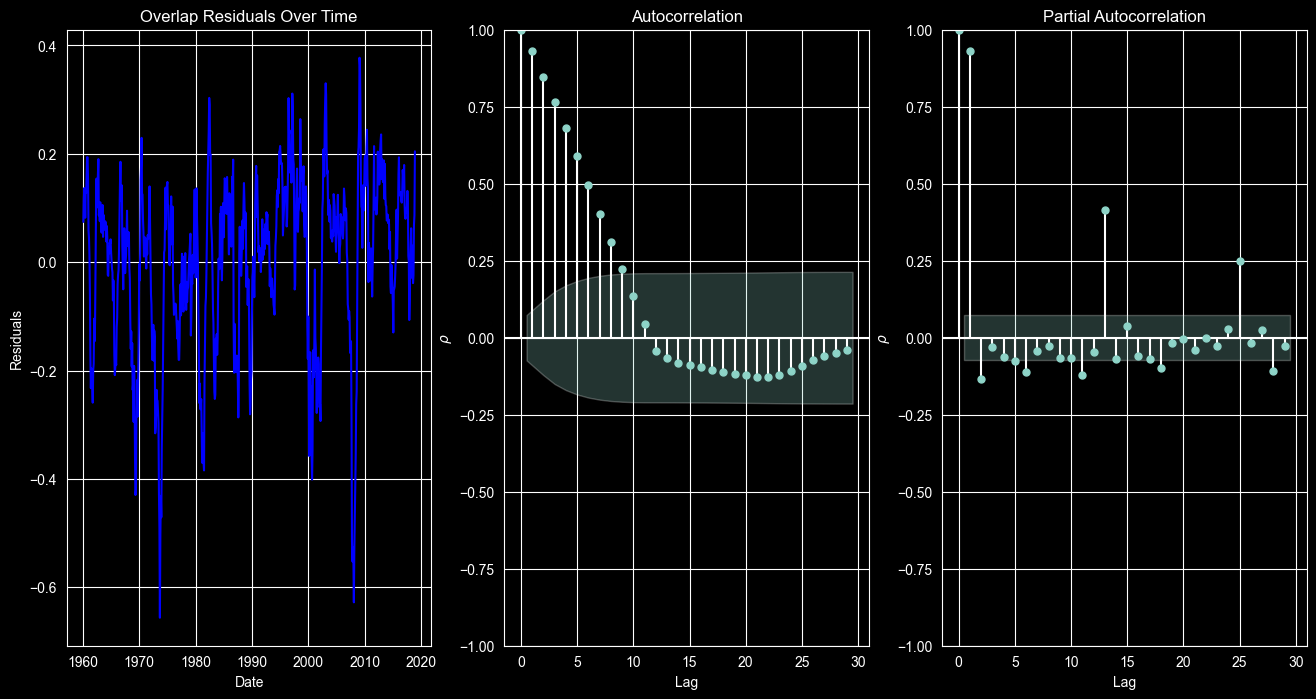

In [218]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=overlap_reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('$\\rho$')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('$\\rho$')
acf = plot_acf(x=overlap_reg.resid, ax=axes[1])
pacf = plot_pacf(x=overlap_reg.resid, ax=axes[2])
plt.show()

Looking at the residuals, PACF, and ACF it looks like the residuals follow an AR(1) process possible with a S-AR component at longer lags. We can confirm this by fitting an AR(1) and looking at the residuals of that to see if we can capture the dynamics of the process. The standard errors used here are the HAC errors, which correct for the autocorrelation and heteroskedasticity in the data.

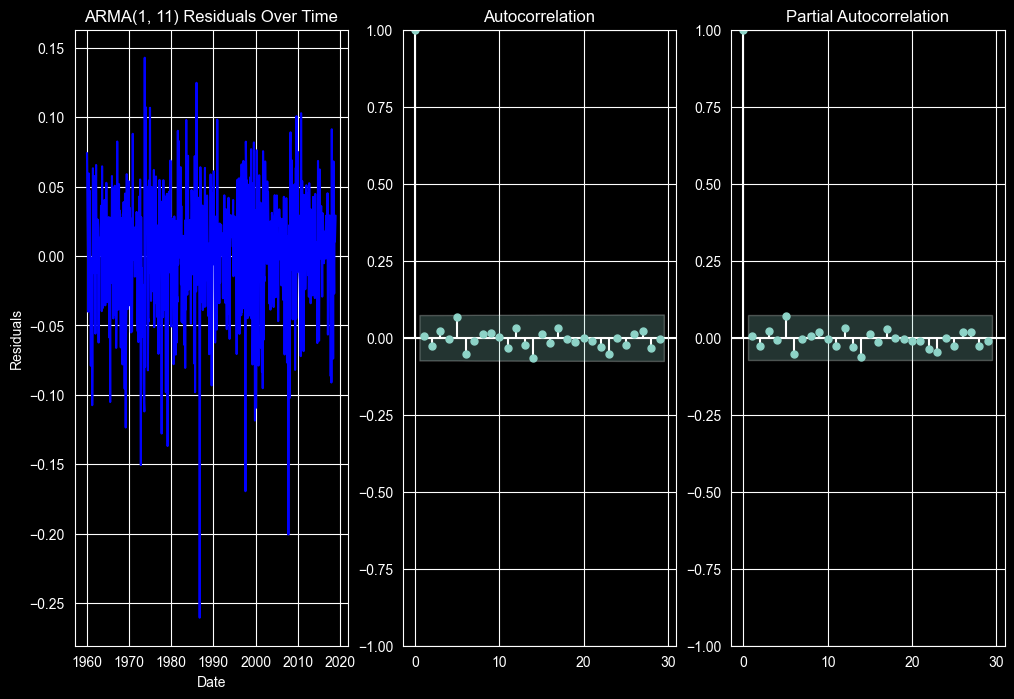

In [219]:
arima = ARIMA(overlap_reg.resid, order=(1, 0, 11), trend='n').fit(method='innovations_mle')
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=arima.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('ARMA(1, 11) Residuals Over Time')
acf = plot_acf(x=arima.resid, ax=axes[1])
pacf = plot_pacf(x=arima.resid, ax=axes[2])
plt.show()

In [220]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  707
Model:                ARIMA(1, 0, 11)   Log Likelihood                1201.139
Date:                Tue, 17 Feb 2026   AIC                          -2376.278
Time:                        21:30:39   BIC                          -2316.985
Sample:                             0   HQIC                         -2353.368
                                - 707                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0754      0.034      2.242      0.025       0.009       0.141
ma.L1          1.0083      0.046     21.766      0.000       0.918       1.099
ma.L2          0.9886      0.040     24.827      0.000       0.911       1.067
ma.L3          0.9865      0.035     27.803      0.000       0.917       1.056
ma.L4          1.0032      0.051     19.635      0.000       0.903       1.103
ma.L5          1.0004      0.044     22.618      0.000       0.914       1.087
ma.L6          1.0023      0.054     18.703      0.000       0.897       1.107
ma.L7          0.9987      0.038     26.088      0.000       0.924       1.074
ma.L8          0.9601      0.049     19.484      0.000       0.864       1.057
ma.L9          0.9269      0.042     22.285      0.000       0.845       1.008
ma.L10         0.9310      0.028     32.929      0.000       0.876       0.986
ma.L11         0.9579      0.054     17.758      0.000       0.852       1.064
sigma2         0.0019      0.000     15.259      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               269.59
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                            -0.76
Prob(H) (two-sided):                  0.97   Kurtosis:                         5.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

With an AR(1) it looks like we can capture a lot of the dynamics of the series, leaving white noise.

In [221]:
overlap_reg2 = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 11})
overlap_reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.997
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0839
Time:                        21:30:39   Log-Likelihood:                 296.06
No. Observations:                 707   AIC:                            -588.1
Df Residuals:                     705   BIC:                            -579.0
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0288      0.053     -0.541      0.589      -0.133       0.076
dividend_yield     2.7782      1.605      1.731      0.083      -0.367       5.924
==============================================================================
Omnibus:                      101.581   Durbin-Watson:                   0.138
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.732
Skew:                          -0.971   Prob(JB):                     6.84e-34
Kurtosis:                       4.190   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 11 lags and without small sample correction
"""

In [222]:
print(overlap_reg2.t_test('dividend_yield = 0'))
print(f'R-Squared: {0.029}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.7782      1.605      1.731      0.083      -0.367       5.924
R-Squared: 0.029
